Sales Analysis

import neccessary libraries 

In [15]:
import pandas as pd
import os 

task1: merge 12 months of sales data into a single csv file

In [130]:
df = pd.read_csv('C:/Users/dhruv/python/1-pybasics/sales_data/Sales_April_2019.csv') 
files = [file for file in os.listdir('C:/Users/dhruv/python/1-pybasics/sales_data')] 
all_months_data = pd.DataFrame() 
for file in files:
    df = pd.read_csv('C:/Users/dhruv/python/1-pybasics/sales_data/'+file) 
    all_months_data = pd.concat([all_months_data,df]) 

all_months_data.to_csv('all_data.csv', index=False)  

Read in updated DataFrame


In [131]:
all_data = pd.read_csv('all_data.csv')
all_data.head()   

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


### Clean up the Data 

##### Drop rows of NAN

In [132]:
nan_df = all_data[all_data.isna().any(axis=1)]
nan_df.head() 

all_data = all_data.dropna(how='all')
all_data.head()    

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


##### Find 'Or' and delete it

In [133]:
all_data = all_data[all_data['Order Date'].str[0:2] != 'Or'] 

#### Convert columns to correct data type

In [134]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered']) #make int
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'])  #make float 

### Augment Data with additional columns

Task 2: Add Months Column 

In [135]:
all_data['month'] = all_data['Order Date'].str[0:2]  
all_data['month'] = all_data['month'].astype('int32') 
all_data.head()   

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4


#### Task 3: Add a Sales Column 

In [136]:
all_data['sales'] = all_data['Quantity Ordered'] * all_data['Price Each'] 
all_data.head()  

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99


#### Task 4: Add a city column

In [137]:
# let's use the apply method()

all_data['City'] = all_data['Purchase Address'].apply(lambda x: x.split(',')[1] +' '+ x.split(',')[2].split(' ')[1])
all_data.head()  

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,City
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas TX
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston MA
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles CA
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles CA
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles CA


##### Question 1: what was the best month for sales? how much was earned that month? 

In [138]:
result= all_data.groupby('month').sum()['sales']  

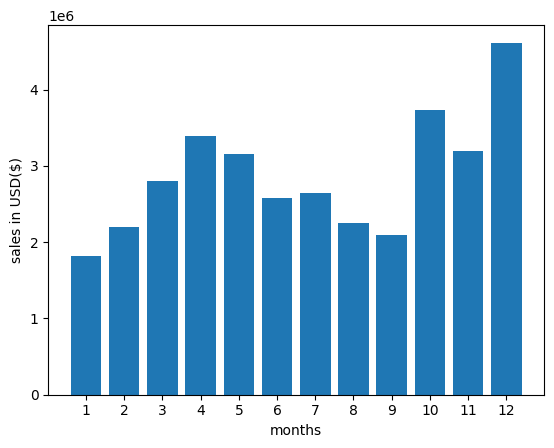

In [ ]:
import matplotlib.pyplot as plt 
months = range(1,13) 


plt.bar(months, result)
plt.xticks(months) 
plt.ylabel('sales in USD($)') 
plt.xlabel('months') 
plt.show()       


#### Question 2: What City had the highest number of sales?

In [79]:
result = all_data.groupby('City').sum()['sales'] 
result 

City
Atlanta GA          2795498.58
Austin TX           1819581.75
Boston MA           3661642.01
Dallas TX           2767975.40
Los Angeles CA      5452570.80
New York City NY    4664317.43
Portland ME          449758.27
Portland OR         1870732.34
San Francisco CA    8262203.91
Seattle WA          2747755.48
Name: sales, dtype: float64

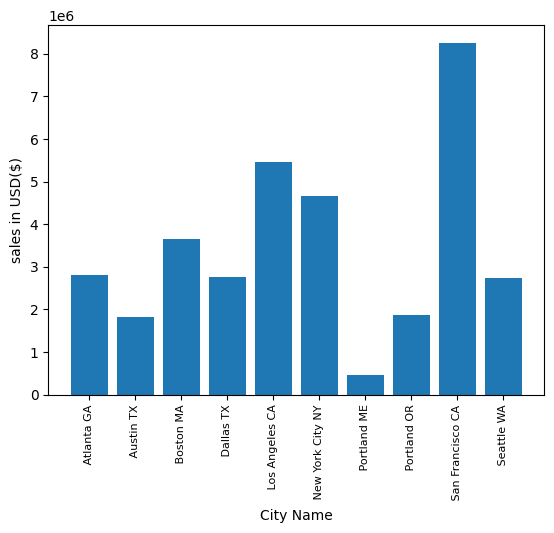

In [ ]:
import matplotlib.pyplot as plt 
cities = [city for city, df in all_data.groupby('City')] 

plt.bar(cities, result)
plt.xticks(cities, rotation='vertical', size=8) 
plt.ylabel('sales in USD($)') 
plt.xlabel('City Name') 
plt.show()         


#### Question 3: What time should we display advertisements to maximize likelihood of customer's buying product ?

In [142]:
all_data['Order Date'] = pd.to_datetime(all_data['Order Date']) 
all_data.head() 

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas TX
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston MA
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles CA
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles CA
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles CA


In [147]:
all_data['Hour'] = all_data['Order Date'].dt.hour 
all_data['Minute'] = all_data['Order Date'].dt.minute
all_data.head()   

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,month,sales,City,Hour,Minute
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas TX,8,46
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston MA,22,30
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles CA,14,38
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles CA,14,38
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles CA,9,27


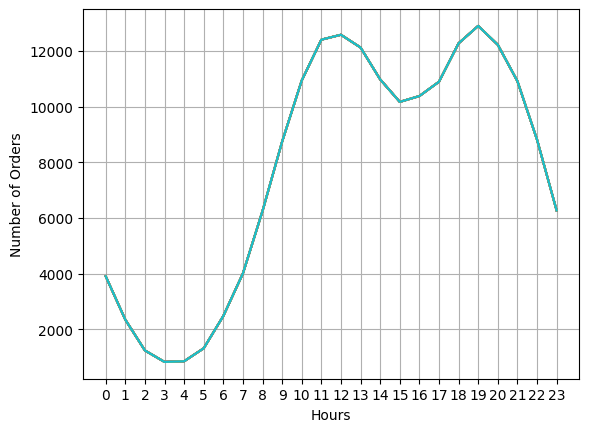

In [155]:
hours = [hour for hour, df in all_data.groupby('Hour')] 
plt.plot(hours, all_data.groupby(['Hour']).count()) 
plt.xticks(hours)
plt.xlabel('Hours')
plt.ylabel('Number of Orders') 
plt.grid() 
plt.show()      


# My recommendation is around 11am (11) or 7pm (19)      

#### Question 4: What Products are most often sold together ?

In [160]:
df = all_data[all_data['Order ID'].duplicated(keep=False)]
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df = df[['Order ID', 'Grouped']].drop_duplicates()
df.head()     

,Order ID,Grouped
3,176560,"Google Phone,Wired Headphones"
18,176574,"Google Phone,USB-C Charging Cable"
30,176585,"Bose SoundSport Headphones,Bose SoundSport Hea..."
32,176586,"AAA Batteries (4-pack),Google Phone"
119,176672,"Lightning Charging Cable,USB-C Charging Cable"


In [168]:
from itertools import combinations
from collections import Counter

count = Counter()  
for row in df['Grouped']:
    row_list = row.split(',') 
    count.update(Counter(combinations(row_list, 2)))

for key, value in count.most_common(10):
    print(key, value)   

('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 160
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92


#### Question 5: What Product sold the most? Why do you think it sold the most? 

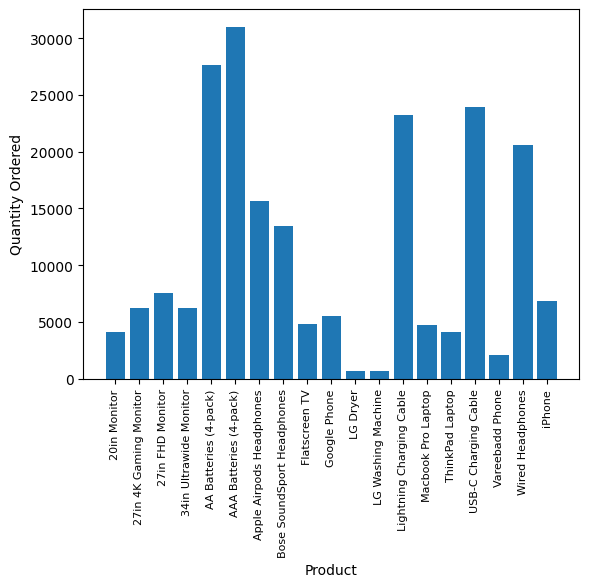

In [211]:
product_group = all_data.groupby('Product') 
quantity_ordered = product_group.sum(numeric_only=True)['Quantity Ordered']  
product = [product for product, df in product_group] 


plt.bar(product, quantity_ordered)  
plt.ylabel('Quantity Ordered')
plt.xlabel('Product')  
plt.xticks(product, rotation='vertical', size=8)  
plt.show()        

C:\Users\dhruv\AppData\Local\Temp\ipykernel_31916\219156986.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(product, rotation='vertical', size=8)


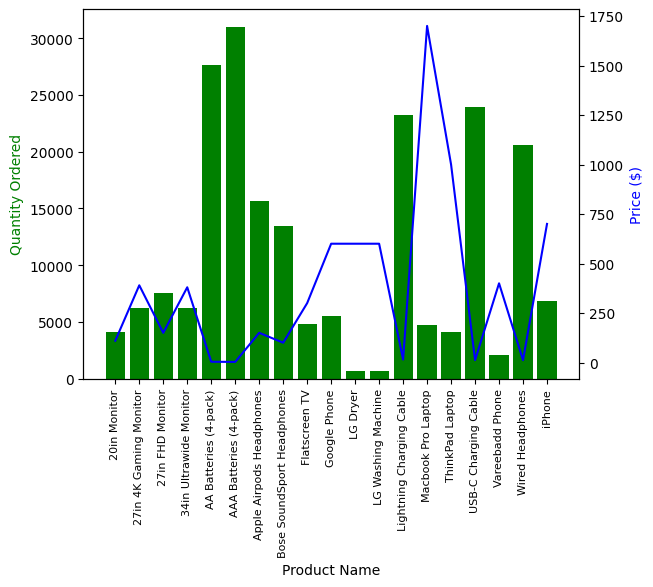

In [ ]:
prices = all_data.groupby('Product').mean(numeric_only=True)['Price Each']   

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.bar(product, quantity_ordered, color='g')
ax2.plot(product, prices, 'b-') 

ax1.set_xlabel('Product Name')
ax1.set_ylabel('Quantity Ordered', color='g')
ax2.set_ylabel('Price ($)', color='b')
ax1.set_xticklabels(product, rotation='vertical', size=8)

plt.show()       